## Credit Default Swap and Structured Finance

### Miniproject 3 | Valuation For Financial Engineering

Team:
- Jiayi Chen
- Binny Singla

## The underlying assets

A bank has placed 10 speculative grade corporate bonds in a CDO it is looking to sell.  Each bond is 5 years in duration, makes quarterly coupon payments at an annual coupon rate of 6%, and the annual default probability is 4%.  The LGD is 60% for all bonds.  The market YTM on the bonds is 9%, and the risk-free interest rate is 1% per year.  The “correlation” between any two bonds’ default dates is equal to a constant of 0.20.  The bonds’ face values are $10 MM each.

## The CDO

The structuring group has proposed two PACs for the CDO.  The Class A tranche has an initial notional value of $20 MM and a coupon rate of 2% per year.  The Class B tranche has a notional value of $10 MM and a coupon rate of 4% per year.  The bank will retain the residuals as equity.

## The Waterfall

The waterfall is as follows:  Class A is paid first from available cash flows, and then Class B is paid.  The residual goes to the bank.  There are no carry-forwards, all cash flows are distributed as earned.  Suggestion:  Compute promised cash flows of the collateral, adjust the cash flows for default times, and distribute the cash flows according to the waterfall.

## Task 1.

Build a simulation model of the aggregate quarterly cash flows of the portfolio, as a function of the quarterly cash flows.  Be sure to correlate the simulated default dates.

## Task 2.

Apply the waterfall rules to determine the cash flow patterns to each class.

## Task 3.

Provide a statistical analysis of the cash flows (both the collateral and the classes) in a report suitable for a bank client.  Be sure to include probability distributions of the outcomes, and key sensitivities to the parameters.




# Tools Setup

In [2]:
# Libraries
import pandas as pd
import numpy as np
import os
import sys
from pathlib import Path
from datetime import datetime

# Change working directory to the project root
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)
    
PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT))

print("PROJECT ROOT:", PROJECT_ROOT)

PROJECT ROOT: /Users/chenjiayi/Credit Default Swap | Structured Finance


## Task 1

- Step 1: Generate fixed random numbers (1000 cases for 10 bonds)

In [5]:
np.random.seed(42)                     
Z = np.random.normal(0, 1, size=(1000, 10))

raw_path = PROJECT_ROOT / "data" / "raw" / "fixed_normals.csv"
np.savetxt(raw_path, Z, delimiter=",")
print("Saved to:", raw_path)

Saved to: /Users/chenjiayi/Credit Default Swap | Structured Finance/data/raw/fixed_normals.csv


- Step 2: Moment matching

A sample of 1,000 standard normal draws will not have a mean of exactly 0 and a standard deviation of exactly 1. Small deviations shift each bond's simulated default rate away from its true value. For example, a column mean of −0.06 raises the 5-year default probability from about 18.5% to about 20.2%. That would overstate expected losses purely because of sampling noise.

To remove this sampling error, each column (bond) is rescaled to have exactly zero mean and unit standard deviation:

$$\tilde{z}_{i,j} = \frac{z_{i,j} - \bar{z}_j}{s_j}$$

where $\bar{z}_j$ and $s_j$ are the sample mean and standard deviation of bond $j$'s 1,000 draws.

This adds no new information. It removes a sampling accident whose correct answer we already know. It also makes Part 2's parameter comparisons cleaner: the moment-matched draws are reused across all scenarios, so differences in results reflect parameter changes rather than noise.

In [6]:
Z_mm = (Z - Z.mean(axis=0)) / Z.std(axis=0)

In [8]:
print("Before adjustment - Mean:", Z.mean(axis=0).round(4))
print("Before adjustment - Standard Deviation:", Z.std(axis=0).round(4))
print("After adjustment - Mean:", Z_mm.mean(axis=0).round(4))   # Should all be 0
print("After adjustment - Standard Deviation:", Z_mm.std(axis=0).round(4))  # Should all be 1

Before adjustment - Mean: [ 0.0108  0.0313 -0.0225 -0.0431  0.0136 -0.0293 -0.0027  0.0055 -0.0231
  0.0381]
Before adjustment - Standard Deviation: [1.0049 1.0155 0.9829 0.9829 1.0121 1.0365 1.0307 1.0304 0.9864 0.9448]
After adjustment - Mean: [-0.  0.  0.  0. -0.  0. -0. -0. -0. -0.]
After adjustment - Standard Deviation: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


- Step 3: Sorting

Sort the 1000 cases from worst to best, so the case number itself means something: case 1 is the worst scenario, case 1000 the best.

In [9]:
row_sums = Z_mm.sum(axis=1)          # one sum per case (row)
order = np.argsort(row_sums)         # ascending: most negative first
Z_sorted = Z_mm[order]               # reorder whole rows

In [10]:
# Check that the sorting worked and that the column means and SDs are still correct
s = Z_sorted.sum(axis=1)
print("Worst 5 case sums:", s[:5].round(2))     # most negative
print("Best 5 case sums:",  s[-5:].round(2))    # most positive
print("Sorted correctly:", np.all(np.diff(s) >= 0))   # True
print("Column means still 0:", np.allclose(Z_sorted.mean(axis=0), 0))
print("Column SDs still 1:",   np.allclose(Z_sorted.std(axis=0), 1))

Worst 5 case sums: [-11.56 -10.    -9.1   -8.19  -8.06]
Best 5 case sums: [ 7.84  8.61  9.06  9.9  10.2 ]
Sorted correctly: True
Column means still 0: True
Column SDs still 1: True


In [11]:
# label the cases and bonds, and convert to a DataFrame for easier viewing
Z_df = pd.DataFrame(Z_sorted,
                    index=pd.RangeIndex(1, 1001, name="Case"),
                    columns=[f"Bond_{j}" for j in range(1, 11)])
Z_df.head()

,Bond_1,Bond_2,Bond_3,Bond_4,Bond_5,Bond_6,Bond_7,Bond_8,Bond_9,Bond_10
Case,,,,,,,,,,
1,-2.384148,-0.587424,-1.820628,-0.923392,-3.114332,-0.103943,-1.105304,0.052802,-1.624183,0.047424
2,-1.548093,-0.561867,0.416050,0.896151,-0.684543,-2.783395,0.510240,-1.189597,-2.021827,-3.038100
3,0.428761,-1.442608,-0.829063,-2.099688,-1.420339,0.200463,-1.903385,-1.442716,0.021022,-0.615691
4,-1.712946,-0.417890,-1.572375,-1.474581,-1.002764,-0.861488,-0.923562,0.497574,-0.489769,-0.230331
5,0.735333,-2.014887,0.363087,-0.251198,-0.841903,-0.688115,-0.205536,-3.500018,-0.687569,-0.967304


- Step 4: Correlated normals via Cholesky decomposition

To give every pair of bonds a correlation of $\rho = 0.20$, we follow the Cholesky method. The target correlation matrix $R$ is $10 \times 10$ with 1 on the diagonal and 0.20 elsewhere. Since each variable has unit variance, $R$ is also the covariance matrix $\Sigma$. Factor it as

$$R = LL^T$$

where $L$ is lower triangular. Then

$$Y = L \cdot Z, \quad Z = (Z_1, \dots, Z_{10}) \text{ iid } N(0,1)$$

produces correlated standard normals (the mean vector is $\mu = 0$). This works because $\text{Cov}(LZ) = L \cdot I \cdot L^T = LL^T = R$. The factorization exists because $R$ is positive definite.

We verify that $LL^T$ recovers $R$, and that the empirical correlation of the 1,000 simulated cases matches the 0.20 target within sampling noise.

In [12]:
# Target correlation matrix: 10 bonds, pairwise correlation 0.20
rho = 0.20
n_bonds = 10
R = np.full((n_bonds, n_bonds), rho)
np.fill_diagonal(R, 1.0)

In [14]:
# Cholesky factorization
L = np.linalg.cholesky(R)
print("L (first 5 rows/cols) =")
print(L[:5, :5].round(10))

L (first 5 rows/cols) =
[[1.         0.         0.         0.         0.        ]
 [0.2        0.9797959  0.         0.         0.        ]
 [0.2        0.16329932 0.96609178 0.         0.        ]
 [0.2        0.16329932 0.13801311 0.95618289 0.        ]
 [0.2        0.16329932 0.13801311 0.11952286 0.9486833 ]]


In [15]:
# Verify: L L^T should equal R
print("\nL L^T equals R:", np.allclose(L @ L.T, R))


L L^T equals R: True


In [ ]:
# Generate correlated normals 
z = Z_sorted.T          # shape (10, 1000): rows = bonds, cols = cases
y = L @ z               # correlated normals, same shape
Y = y.T                 # back to (1000, 10): rows = cases, cols = bonds

In [21]:
# Display the matrices for the first 5 bonds and first 5 cases
print("z = Z_sorted.T (first 5 bonds × first 5 cases):")
print(z[:5, :5].round(3))

print("\ny = L @ z (first 5 bonds × first 5 cases):")
print(y[:5, :5].round(3))

print("\nY = y.T (first 5 cases × first 5 bonds):")
print(Y[:5, :5].round(3))

z = Z_sorted.T (first 5 bonds × first 5 cases):
[[-2.384 -1.548  0.429 -1.713  0.735]
 [-0.587 -0.562 -1.443 -0.418 -2.015]
 [-1.821  0.416 -0.829 -1.572  0.363]
 [-0.923  0.896 -2.1   -1.475 -0.251]
 [-3.114 -0.685 -1.42  -1.003 -0.842]]

y = L @ z (first 5 bonds × first 5 cases):
[[-2.384e+00 -1.548e+00  4.290e-01 -1.713e+00  7.350e-01]
 [-1.052e+00 -8.600e-01 -1.328e+00 -7.520e-01 -1.827e+00]
 [-2.332e+00  1.000e-03 -9.510e-01 -1.930e+00  1.690e-01]
 [-1.707e+00  5.130e-01 -2.272e+00 -2.038e+00 -3.720e-01]
 [-3.889e+00 -8.860e-01 -1.863e+00 -1.755e+00 -9.610e-01]]

Y = y.T (first 5 cases × first 5 bonds):
[[-2.384e+00 -1.052e+00 -2.332e+00 -1.707e+00 -3.889e+00]
 [-1.548e+00 -8.600e-01  1.000e-03  5.130e-01 -8.860e-01]
 [ 4.290e-01 -1.328e+00 -9.510e-01 -2.272e+00 -1.863e+00]
 [-1.713e+00 -7.520e-01 -1.930e+00 -2.038e+00 -1.755e+00]
 [ 7.350e-01 -1.827e+00  1.690e-01 -3.720e-01 -9.610e-01]]


In [19]:
# Verify empirical correlation matches the target
corr = np.corrcoef(y)   
off_diag = corr[~np.eye(n_bonds, dtype=bool)]
print("\nEmpirical correlation (first 5 bonds):")
print(corr[:5, :5].round(3))
print(f"Average pairwise correlation: {off_diag.mean():.4f} (target {rho})")


Empirical correlation (first 5 bonds):
[[1.    0.215 0.23  0.231 0.194]
 [0.215 1.    0.208 0.194 0.209]
 [0.23  0.208 1.    0.195 0.214]
 [0.231 0.194 0.195 1.    0.18 ]
 [0.194 0.209 0.214 0.18  1.   ]]
Average pairwise correlation: 0.1978 (target 0.2)


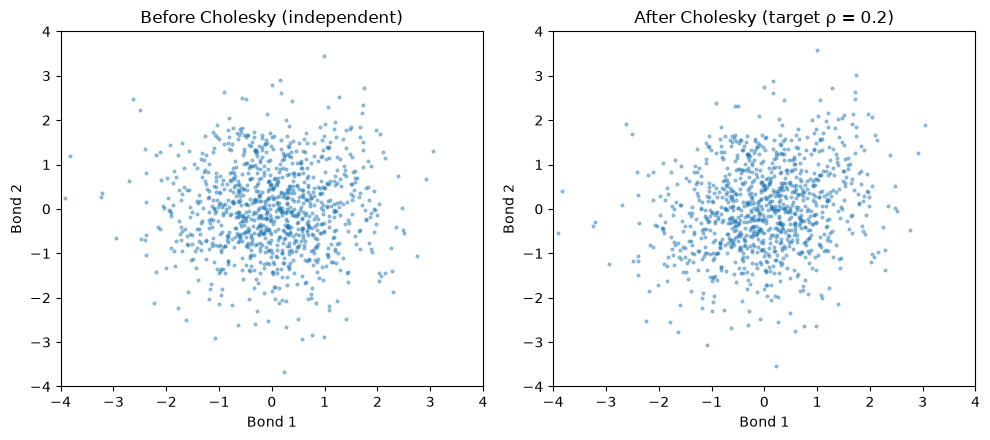

In [22]:
# Visualize the results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].scatter(Z_sorted[:, 0], Z_sorted[:, 1], s=4, alpha=0.4)
axes[0].set_title("Before Cholesky (independent)")
axes[1].scatter(Y[:, 0], Y[:, 1], s=4, alpha=0.4)
axes[1].set_title(f"After Cholesky (target ρ = {rho})")
for ax in axes:
    ax.set_xlabel("Bond 1"); ax.set_ylabel("Bond 2")
    ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
plt.tight_layout()
plt.show()

- Step 5: Correlated default times (Gaussian copula, exponential marginals)

The correlated normals are converted to default times in two steps:

1. Map to correlated uniforms with the standard normal CDF: $U_{i,j} = \Phi(Y_{i,j})$.
2. Apply the exponential inverse CDF: $\tau_{i,j} = -\ln(1 - U_{i,j})/\lambda$.

The hazard rate is set so that the annual default probability is exactly 4%: $\lambda = -\ln(1 - 0.04) \approx 0.0408$. We use $1 - U$ (rather than $U$) so that a low normal draw maps to an early default, consistent with the worst-to-best ordering in Step 3.

Default times are converted to quarters ($\tau \times 4$). A bond defaults in quarter $\lceil 4\tau \rceil$ if $4\tau \le 20$, and survives to maturity otherwise. Each bond's marginal default probability is unchanged by the correlation; what changes is that defaults cluster in the same cases, which fattens the tail of the number-of-defaults distribution.

In [24]:
# C alculate default times from correlated normals
from scipy.stats import norm

# Parameters
PD = 0.04                          # annual default probability
lam = -np.log(1 - PD)              # hazard rate ≈ 0.0408
T_quarters = 20                    # 5 years × 4 quarters

# 1. Normal -> uniform
U = norm.cdf(Y)                    # shape (1000, 10)

# 2. Uniform -> default time (years); low Y -> early default
tau_years = -np.log(1 - U) / lam

# 3. Default quarter: 1..20 = quarter of default, 0 = survives
tau_q = tau_years * 4
default_q = np.where(tau_q <= T_quarters, np.ceil(tau_q), 0).astype(int)

In [25]:
# Print first 5 cases × 5 bonds
print(f"lambda = {lam:.4f}")
print("\nU (first 5 cases × 5 bonds):")
print(U[:5, :5].round(3))
print("\nDefault time in quarters:")
print(tau_q[:5, :5].round(2))
print("\nDefault quarter (0 = survives):")
print(default_q[:5, :5])

lambda = 0.0408

U (first 5 cases × 5 bonds):
[[0.009 0.146 0.01  0.044 0.   ]
 [0.061 0.195 0.5   0.696 0.188]
 [0.666 0.092 0.171 0.012 0.031]
 [0.043 0.226 0.027 0.021 0.04 ]
 [0.769 0.034 0.567 0.355 0.168]]

Default time in quarters:
[[  0.84  15.5    0.97   4.4    0.  ]
 [  6.15  21.24  67.96 116.68  20.37]
 [107.44   9.47  18.36   1.14   3.11]
 [  4.34  25.1    2.66   2.06   3.96]
 [143.55   3.37  82.02  42.96  18.07]]

Default quarter (0 = survives):
[[ 1 16  1  5  1]
 [ 7  0  0  0  0]
 [ 0 10 19  2  4]
 [ 5  0  3  3  4]
 [ 0  4  0  0 19]]


In [26]:
# Cross-check: 5-year default probability
defaulted = default_q > 0                   # True = defaults within 5 years
n_defaults = defaulted.sum(axis=1)          # number of defaults per case
pi5 = 1 - (1 - PD)**5                       # 5-year default probability ≈ 0.1846

# 1. Marginal default rates
print(f"1-yr default rate: {(tau_years <= 1).mean():.4f} (target {PD})")
print(f"5-yr default rate: {defaulted.mean():.4f} (target {pi5:.4f})")
print(f"Avg defaults per case: {n_defaults.mean():.3f} (target {10*pi5:.3f})")

# 2. Clustering: correlated vs independent
from scipy.stats import binom
p5_sim = (n_defaults >= 5).mean()
p5_ind = 1 - binom.cdf(4, 10, pi5)
print(f"\nP(5+ defaults): simulated {p5_sim:.4f} vs independent {p5_ind:.4f}")

# 3. Distribution of number of defaults
print("\nNumber of defaults per case:")
print(pd.Series(n_defaults).value_counts().sort_index())

# 4. Sorting check: worst vs best cases
print("\nDefaults in worst 10 cases:", n_defaults[:10])
print("Defaults in best 10 cases: ", n_defaults[-10:])

1-yr default rate: 0.0410 (target 0.04)
5-yr default rate: 0.1827 (target 0.1846)
Avg defaults per case: 1.827 (target 1.846)

P(5+ defaults): simulated 0.0840 vs independent 0.0237

Number of defaults per case:
0     245
1     270
2     207
3     119
4      75
5      45
6      21
7      12
8       4
9       1
10      1
Name: count, dtype: int64

Defaults in worst 10 cases: [10  5  8  8  6  8  6  5  9  7]
Defaults in best 10 cases:  [0 0 0 0 0 1 0 0 0 0]


We notice: 
- **Right-skewed with a long tail:** most cases are mild (72% have 0–2 defaults), but 8.4% have 5+ defaults, and the worst case has all 10 bonds defaulting.
- **The mean understates the risk:** an average of 1.83 defaults hides the tail scenarios that drive tranche losses.

- Step 6: Bond cash flows

Each bond's promised schedule is a quarterly coupon of $10\text{MM} \times 6\%/4 = 0.15\text{MM}$, plus the 10MM face value at Q20. Following the defaultable bond model in §5.4, a default in quarter $d$ truncates this schedule:

| Situation | Cash flow ($MM) |
|---|---|
| Quarters before $d$ | 0.15 coupon |
| Default quarter $d$ | Recovery $(1 - 60\%) \times 10 = 4$, no coupon |
| After $d$ | 0 |
| No default | 0.15 each quarter, plus 10 at Q20 |

The result is a 1,000 × 10 × 20 array (cases × bonds × quarters). `show_case(n)` displays the 10 × 20 cash-flow table for any case $n$ from 1 to 1,000.

In [27]:
# Bond parameters (all amounts in $MM)
face = 10.0                       # face value of each bond
coupon_rate = 0.06                # annual coupon rate
LGD = 0.60                        # loss given default

coupon = face * coupon_rate / 4   # quarterly coupon = 0.15
recovery = face * (1 - LGD)       # recovery at default = 4.0

n_cases = 1000
n_bonds = 10
n_quarters = 20

In [32]:
from src.cdo_funs import bond_cash_flows, all_bond_cash_flows, portfolio_cash_flows

In [34]:
# Theoretical promised cash flows for the first 5 bonds (no defaults)
bond_names = [f"Bond_{j}" for j in range(1, 6)]
quarter_names = [f"Q{q}" for q in range(1, 21)]

promised = pd.DataFrame(
    [bond_cash_flows(0) for _ in range(5)],   # 0 = no default
    index=bond_names, columns=quarter_names
)

print(" Theoretical Promised cash flows, first 5 bonds ($MM):")
display(promised.round(2))

 Theoretical Promised cash flows, first 5 bonds ($MM):


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
Bond_1,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_2,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_3,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_4,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15
Bond_5,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,10.15


In [36]:
# Calculate actual cash flows for all bonds and all cases
bond_cf = all_bond_cash_flows(default_q)      # default_q comes from Step 5
print("bond_cf shape:", bond_cf.shape)        # (1000, 10, 20)

bond_cf shape: (1000, 10, 20)


In [40]:
# See Actual Cash Flows for a specific case
case = 1   # pick any case from 1 to 1000

actual = pd.DataFrame(
    bond_cf[case - 1, :5],
    index=bond_names, columns=quarter_names
)
actual.insert(0, "Default Q", default_q[case - 1, :5])   # 0 = no default

print(f"Actual cash flows in case {case}, first 5 bonds ($MM):")
display(actual.round(2))

Actual cash flows in case 1, first 5 bonds ($MM):


,Default Q,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,...,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
Bond_1,1,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
Bond_2,16,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,0.15,...,0.15,0.15,0.15,0.15,0.15,4.0,0.0,0.0,0.0,0.0
Bond_3,1,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
Bond_4,5,0.15,0.15,0.15,0.15,4.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0
Bond_5,1,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0


- Step 7: Portfolio cash flows

Summing the 10 bonds' cash flows gives the portfolio's quarterly cash flows: a 1,000 × 20 table (cases × quarters). This is the final output of Task 1 and the input to the waterfall in Task 2.

**Check against the analytic expectation** With survival probability $S(t) = e^{-\lambda t}$, the expected cash flow of one bond in quarter $q$ is

$$E[CF_q] = 0.15 \cdot S\!\left(\tfrac{q}{4}\right) + 4 \cdot \left[S\!\left(\tfrac{q-1}{4}\right) - S\!\left(\tfrac{q}{4}\right)\right] \;\big(+\,10 \cdot S(5) \text{ at } q = 20\big)$$

that is, the coupon if the bond survives the quarter, plus recovery if it defaults during the quarter. The portfolio expectation is 10 times this. The simulated mean across the 1,000 cases should match it closely, and both lie below the promised schedule (1.5MM per quarter, 101.5MM at Q20) because of expected default losses.

In [41]:
# Portfolio Quarterly Cash Flows: sum across all bonds for each case
port_cf = portfolio_cash_flows(bond_cf)       # shape (1000, 20): cases × quarters

port_df = pd.DataFrame(port_cf,
                       index=pd.RangeIndex(1, 1001, name="Case"),
                       columns=[f"Q{q}" for q in range(1, 21)])

print("Portfolio cash flows, first 5 cases ($MM):")
display(port_df.head().round(2))

Portfolio cash flows, first 5 cases ($MM):


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20
Case,,,,,,,,,,,,,,,,,,,,
1,16.90,4.75,0.75,0.75,4.60,0.6,0.60,4.45,4.30,4.15,0.15,0.15,0.15,0.15,0.15,4.00,0.00,0.00,0.00,0.00
2,13.05,1.05,1.05,1.05,1.05,4.9,4.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,0.75,50.75
3,5.35,9.05,1.05,4.90,0.90,0.9,4.75,0.75,0.75,4.60,0.60,0.60,0.60,0.60,0.60,0.60,0.60,0.60,4.45,24.30
4,1.50,1.50,9.20,8.90,8.60,0.6,4.45,0.45,0.45,0.45,4.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,0.30,20.30
5,5.35,1.35,1.35,5.20,1.20,1.2,5.05,1.05,1.05,1.05,1.05,4.90,0.90,0.90,0.90,0.90,0.90,0.90,4.75,44.60


In [42]:
# Cross-check: expected cash flows vs simulated mean
lam = hazard_rate if False else -np.log(1 - 0.04)
q = np.arange(1, 21)
S_prev = np.exp(-lam * (q - 1) / 4)        # survival to start of quarter
S_curr = np.exp(-lam * q / 4)              # survival to end of quarter

# Per bond: coupon if survives the quarter, recovery if defaults in it, face at Q20 if survives
exp_bond = 0.15 * S_curr + 4.0 * (S_prev - S_curr)
exp_bond[-1] += 10.0 * S_curr[-1]
exp_port = 10 * exp_bond                   # 10 bonds

check = pd.DataFrame({
    "Promised": [1.5] * 19 + [101.5],
    "Expected (analytic)": exp_port,
    "Simulated mean": port_cf.mean(axis=0)
}, index=[f"Q{q}" for q in range(1, 21)]).round(3)

display(check)

,Promised,Expected (analytic),Simulated mean
Q1,1.5,1.891,1.904
Q2,1.5,1.872,1.823
Q3,1.5,1.853,1.918
Q4,1.5,1.834,1.842
Q5,1.5,1.815,1.858
Q6,1.5,1.797,1.722
Q7,1.5,1.779,1.784
Q8,1.5,1.761,1.777
Q9,1.5,1.743,1.685
Q10,1.5,1.725,1.727


In [43]:
# Standard error of the mean (SE) and difference in terms of SE
se = port_cf.std(axis=0, ddof=1) / np.sqrt(port_cf.shape[0])
check["SE"] = se.round(3)
check["Diff / SE"] = ((check["Simulated mean"] - check["Expected (analytic)"]) / se).round(2)
display(check)
print("All within 3 SE:", (check["Diff / SE"].abs() < 3).all())

,Promised,Expected (analytic),Simulated mean,SE,Diff / SE
Q1,1.5,1.891,1.904,0.045,0.29
Q2,1.5,1.872,1.823,0.036,-1.35
Q3,1.5,1.853,1.918,0.043,1.51
Q4,1.5,1.834,1.842,0.039,0.20
Q5,1.5,1.815,1.858,0.042,1.02
Q6,1.5,1.797,1.722,0.034,-2.23
Q7,1.5,1.779,1.784,0.038,0.13
Q8,1.5,1.761,1.777,0.039,0.41
Q9,1.5,1.743,1.685,0.035,-1.68
Q10,1.5,1.725,1.727,0.036,0.06


All within 3 SE: True


# Task 2